# Лекция 1. Разбор упражнений

Упражнения из раздела 12 конспекта [`lecture01.md`](lecture01.md). Каждое разбирается по одной схеме:

1. **условие**;
2. **решение по шагам** — стандартная форма (табличка $x$, $f$, $g$, $h$), класс задачи, ответ;
3. **проверка кодом** — тот же ответ получаем через `scipy.optimize`, и картинка.

Сначала попробуйте решить сами, потом раскрывайте. Краткие ответы без кода — в [`exercises01.md`](exercises01.md); как пользоваться `scipy.optimize` — в [`demo01.ipynb`](demo01.ipynb).

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import LinearConstraint, linprog, minimize

# та же палитра, что в картинках конспекта (make_figures.py)
BLUE, ORANGE, AQUA, YELLOW, RED, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e34948", "#4a3aa7"
GRAY, INK = "#8a8985", "#0b0b0b"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2, "legend.frameon": False})
rng = np.random.default_rng(1)

## 12.1. Стандартная форма и класс задачи

> Запишите в стандартной форме (NLP) и определите класс:
> (а) $\max_{x \in \mathbb{R}^2} x_1 x_2$ при $x_1 + x_2 = 10$, $x \ge 0$;
> (б) найти точку окружности $x_1^2 + x_2^2 = 1$, ближайшую к точке $(3, 4)$;
> (в) $\min_{x \in \mathbb{R}^n} \Vert Ax - b\Vert_2$ при $\Vert x\Vert_2 \le 1$;
> (г) по измерениям $(t_i, y_i)$, $i = 1, \dots, N$, подобрать параметры $x = (x_1, x_2)$ модели затухания $\varphi(t; x) = x_1 e^{-x_2 t}$ методом наименьших квадратов при условии $x_2 \ge 0$.

Напоминание: стандартная форма — это $\min f(x)$ при $g(x) = 0$, $h(x) \ge 0$. Чтобы определить класс, смотрим на два признака отдельно: **вид функций** (линейные → LP, квадратичная цель → QP, квадратичные ограничения → QCQP, иначе NLP) и **выпуклость**.

### (а) Произведение при фиксированной сумме

**Шаг 1. Стандартная форма.** Максимум превращаем в минимум знаком, равенство переносим в $g$, неотрицательность — в $h$:

| | |
|---|---|
| переменные | $x \in \mathbb{R}^2$ |
| $f(x)$ | $-x_1 x_2$ |
| $g(x) = 0$ | $x_1 + x_2 - 10$ |
| $h(x) \ge 0$ | $(x_1,\; x_2)$ |

**Шаг 2. Класс.** Целевая функция квадратичная: $f(x) = \tfrac12 x^\top Q x$ с

$$Q = \begin{pmatrix} 0 & -1 \\ -1 & 0 \end{pmatrix}$$

(проверьте: $\tfrac12 x^\top Q x = \tfrac12(-x_1x_2 - x_2x_1) = -x_1x_2$). Ограничения линейные. Значит, это **QP**.

Выпукла ли она? QP выпукла тогда и только тогда, когда $Q \succeq 0$. Собственные числа $Q$ равны $\pm 1$: одно отрицательное, поэтому $Q$ индефинитна и задача как QP **невыпукла**.

**Шаг 3. Решение.** Из равенства $x_2 = 10 - x_1$, и на допустимом множестве цель — функция одной переменной:

$$\varphi(x_1) = -x_1(10 - x_1) = x_1^2 - 10 x_1, \qquad 0 \le x_1 \le 10 .$$

Это уже выпуклая парабола, $\varphi'(x_1) = 2x_1 - 10 = 0$ при $x_1 = 5$. Ответ: $x^\ast = (5, 5)$, произведение $25$.

**Обратите внимание.** Формально задача невыпукла (индефинитная $Q$), а на допустимой прямой оказалась выпуклой с единственным решением. Так бывает: классификация «по виду функций» — это верхняя оценка трудности, а не приговор. Локальный метод здесь из любого старта придёт в $(5,5)$.

In [2]:
Q = np.array([[0.0, -1.0], [-1.0, 0.0]])
print("собственные числа Q:", np.linalg.eigvalsh(Q))

f = lambda x: -x[0] * x[1]
cons = [{"type": "eq", "fun": lambda x: x[0] + x[1] - 10}]      # g(x) = 0
res = minimize(f, x0=[1.0, 9.0], method="SLSQP", constraints=cons, bounds=[(0, None), (0, None)])
print("x* =", res.x.round(6), "  произведение =", -res.fun)

собственные числа Q: [-1.  1.]
x* = [5. 5.]   произведение = 25.0


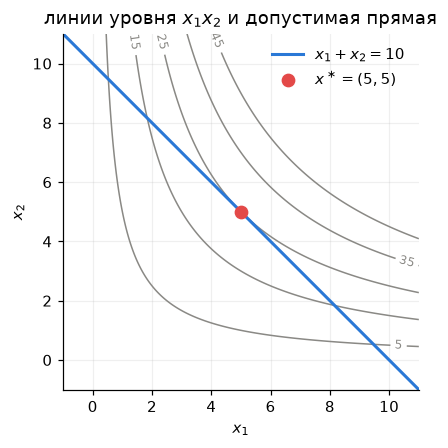

In [3]:
x1 = np.linspace(-1, 11, 300)
X1, X2 = np.meshgrid(x1, x1)
fig, ax = plt.subplots(figsize=(4.6, 4.2))
cs = ax.contour(X1, X2, X1 * X2, levels=[5, 15, 25, 35, 45], colors=GRAY, linewidths=1)
ax.clabel(cs, fmt="%g", fontsize=8)
ax.plot(x1, 10 - x1, color=BLUE, lw=2, label=r"$x_1 + x_2 = 10$")
ax.plot(5, 5, "o", color=RED, ms=8, zorder=5, label=r"$x^\ast = (5, 5)$")
ax.set(xlim=(-1, 11), ylim=(-1, 11), xlabel="$x_1$", ylabel="$x_2$", aspect="equal",
       title="линии уровня $x_1 x_2$ и допустимая прямая")
ax.legend(loc="upper right")
plt.show()

Гиперболы $x_1x_2 = \text{const}$ касаются допустимой прямой в точке $(5,5)$ — та же картина «линии уровня упираются в $\Omega$», что и на рисунке 01 конспекта.

### (б) Ближайшая точка окружности

**Шаг 1. Стандартная форма.** Расстояние до $(3,4)$ удобно минимизировать в квадрате (половина квадрата — чтобы градиент был без двойки; на $\arg\min$ это не влияет):

| | |
|---|---|
| переменные | $x \in \mathbb{R}^2$ |
| $f(x)$ | $\tfrac12\big[(x_1 - 3)^2 + (x_2 - 4)^2\big]$ |
| $g(x) = 0$ | $x_1^2 + x_2^2 - 1$ |
| $h(x) \ge 0$ | нет |

**Шаг 2. Класс.** Цель квадратичная, ограничение квадратичное — **QCQP**. Допустимое множество — окружность, а она **не выпукла**: отрезок между двумя её точками проходит внутри круга, а не по окружности. Значит, задача невыпукла. (Если бы ограничение было $x_1^2 + x_2^2 \le 1$ — круг, — множество было бы выпуклым и задача выпуклой.)

**Шаг 3. Решение.** Геометрически: ближайшая к точке $p = (3,4)$ точка окружности лежит на луче из центра в $p$, то есть $x^\ast = p / \Vert p\Vert = (3, 4)/5 = (0.6, 0.8)$, расстояние $\Vert p\Vert - 1 = 4$.

Есть и вторая «особая» точка — $(-0.6, -0.8)$, самая далёкая от $p$. В ней тоже выполнены условия стационарности (о них — лекция 8), но это максимум. Локальный метод, стартовавший рядом с ней, может в ней и остаться — проверим.

In [4]:
p = np.array([3.0, 4.0])
f = lambda x: 0.5 * np.sum((x - p) ** 2)
cons = [{"type": "eq", "fun": lambda x: x[0] ** 2 + x[1] ** 2 - 1}]

for x0 in ([1.0, 0.0], [0.0, -1.0], [-0.6, -0.8]):
    res = minimize(f, x0=x0, method="SLSQP", constraints=cons)
    print(f"старт {np.array(x0)} -> x* = {res.x.round(4)},  расстояние = {np.sqrt(2 * res.fun):.4f}")

старт [1. 0.] -> x* = [0.6 0.8],  расстояние = 4.0000
старт [ 0. -1.] -> x* = [0.6 0.8],  расстояние = 4.0000
старт [-0.6 -0.8] -> x* = [-0.6 -0.8],  расстояние = 6.0000


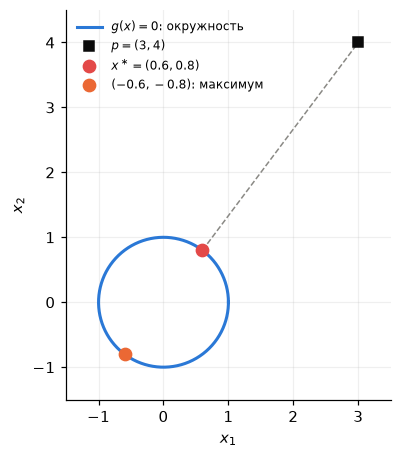

In [5]:
t = np.linspace(0, 2 * np.pi, 200)
fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.plot(np.cos(t), np.sin(t), color=BLUE, lw=2, label=r"$g(x) = 0$: окружность")
ax.plot([0.6, 3], [0.8, 4], color=GRAY, ls="--", lw=1)
ax.plot(3, 4, "s", color=INK, ms=7, label="$p = (3, 4)$")
ax.plot(0.6, 0.8, "o", color=RED, ms=8, zorder=5, label=r"$x^\ast = (0.6, 0.8)$")
ax.plot(-0.6, -0.8, "o", color=ORANGE, ms=8, zorder=5, label="$(-0.6, -0.8)$: максимум")
ax.set(xlim=(-1.5, 3.5), ylim=(-1.5, 4.5), aspect="equal", xlabel="$x_1$", ylabel="$x_2$")
ax.legend(loc="upper left", fontsize=8)
plt.show()

### (в) МНК с ограничением на норму

**Шаг 1. Стандартная форма.** Норма без квадрата $\Vert Ax - b\Vert$ негладкая в точке, где $Ax = b$ (там она ведёт себя как $|t|$). Но $\Vert r\Vert$ и $\tfrac12\Vert r\Vert^2$ минимизируются в одной и той же точке — возведение в квадрат монотонно на $[0, \infty)$. Поэтому берём гладкую версию. Ограничение $\Vert x\Vert \le 1$ по той же причине записываем как $\Vert x\Vert^2 \le 1$:

| | |
|---|---|
| переменные | $x \in \mathbb{R}^n$ |
| $f(x)$ | $\tfrac12 \Vert Ax - b\Vert^2 = \tfrac12 x^\top A^\top A\, x - b^\top A\, x + \tfrac12 b^\top b$ |
| $g(x) = 0$ | нет |
| $h(x) \ge 0$ | $1 - x^\top x$ |

**Шаг 2. Класс.** Цель квадратичная, ограничение квадратичное — **QCQP**. Выпуклость: $A^\top A \succeq 0$ всегда (это $\sum_i (a_i^\top x)^2 \ge 0$), шар $\Vert x\Vert \le 1$ выпуклый. Задача **выпукла**, и любой локальный минимум глобален.

**Шаг 3. Что за задача.** Это МНК с регуляризацией Тихонова, записанной в виде ограничения (в лекции 6 та же задача появится как подзадача метода доверительной области). Два случая:

- решение обычного МНК $x_{LS}$ лежит внутри шара, $\Vert x_{LS}\Vert < 1$ — ограничение **неактивно**, ответ $x^\ast = x_{LS}$;
- $\Vert x_{LS}\Vert > 1$ — ограничение **активно**, решение лежит на сфере $\Vert x^\ast\Vert = 1$ и отличается от $x_{LS}$.

Проверим оба случая на случайной матрице $A$ размера $10 \times 3$.

In [6]:
A = rng.normal(size=(10, 3))
cons = [{"type": "ineq", "fun": lambda x: 1.0 - x @ x}]        # h(x) = 1 - x^T x >= 0

for scale in (0.3, 3.0):
    b = A @ (scale * np.array([1.0, -1.0, 0.5])) + 0.1 * rng.normal(size=10)
    x_ls = np.linalg.lstsq(A, b, rcond=None)[0]
    res = minimize(lambda x: 0.5 * np.sum((A @ x - b) ** 2), x0=np.zeros(3), method="SLSQP", constraints=cons)
    print(f"||x_LS|| = {np.linalg.norm(x_ls):.3f}  ->  ||x*|| = {np.linalg.norm(res.x):.3f},  "
          f"h(x*) = {1 - res.x @ res.x: .4f}  ({'активно' if abs(1 - res.x @ res.x) < 1e-6 else 'неактивно'})")

||x_LS|| = 0.548  ->  ||x*|| = 0.548,  h(x*) =  0.7002  (неактивно)
||x_LS|| = 4.498  ->  ||x*|| = 1.000,  h(x*) = -0.0000  (активно)


### (г) Нелинейный МНК: модель затухания

**Шаг 1. Стандартная форма.** Как и в линейном МНК (пример 7.1 конспекта), минимизируем половину суммы квадратов невязок:

| | |
|---|---|
| переменные | $x = (x_1, x_2) \in \mathbb{R}^2$ — амплитуда и скорость затухания |
| $f(x)$ | $\tfrac12 \sum_{i=1}^N \big(x_1 e^{-x_2 t_i} - y_i\big)^2$ |
| $g(x) = 0$ | нет |
| $h(x) \ge 0$ | $x_2$ |

**Шаг 2. Класс.** Ограничение линейное (просто граница на переменную, в SciPy — `bounds`). А вот цель — **не квадратичная**: модель линейна по $x_1$, но нелинейна по $x_2$, и $f$ не приводится к виду $\tfrac12 x^\top Q x + c^\top x$. Значит, это **NLP** с одним линейным неравенством. Выпуклость, как правило, теряется: при больших $x_2$ экспонента обнуляется, $f$ выходит на плато $\tfrac12\sum y_i^2$, а выпуклая функция так себя вести не может (выпуклая функция, ограниченная сверху на луче, не может расти). Ниже проверим, что гессиан $f$ в такой точке индефинитен.

Структура — сумма квадратов, то есть **нелинейный МНК**. Класс не меняется, но для суммы квадратов есть специальные методы (Гаусс–Ньютон, `scipy.optimize.least_squares`) — лекция 5.

**Шаг 3. Решение.** Аналитического ответа нет, решаем численно. Два полезных наблюдения:

- при фиксированном $x_2$ задача линейна по $x_1$: $x_1(x_2) = \sum_i y_i e^{-x_2 t_i} \big/ \sum_i e^{-2 x_2 t_i}$ — так можно свести задачу к одномерной по $x_2$;
- если данные действительно затухают, ограничение $x_2 \ge 0$ в решении **неактивно**, и его можно было бы не писать; оно страхует от бессмысленных ответов при плохом старте.

In [7]:
t = np.linspace(0, 3, 25)
y = 2.0 * np.exp(-1.5 * t) + 0.05 * rng.normal(size=t.size)         # истинные параметры (2, 1.5)

r = lambda x: x[0] * np.exp(-x[1] * t) - y                            # вектор невязок
f = lambda x: 0.5 * np.sum(r(x) ** 2)

res = minimize(f, x0=[1.0, 0.5], method="SLSQP", bounds=[(None, None), (0, None)])
print(f"minimize:      x* = {res.x.round(4)}, f* = {res.fun:.5f}, h(x*) = x2 = {res.x[1]:.3f} > 0 -> неактивно")

from scipy.optimize import least_squares
res_ls = least_squares(r, x0=[1.0, 0.5], bounds=([-np.inf, 0], [np.inf, np.inf]))
print(f"least_squares: x* = {res_ls.x.round(4)}, f* = {res_ls.cost:.5f}  (та же точка, метод для суммы квадратов)")

def hess_fd(fun, x, eps=1e-4):
    x = np.asarray(x, float); n = x.size; H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            e_i, e_j = np.eye(n)[i] * eps, np.eye(n)[j] * eps
            H[i, j] = (fun(x + e_i + e_j) - fun(x + e_i - e_j) - fun(x - e_i + e_j) + fun(x - e_i - e_j)) / (4 * eps**2)
    return H

for pt in (res.x, np.array([2.0, 4.5])):
    print(f"собственные числа гессиана в {pt.round(2)}: {np.linalg.eigvalsh(hess_fd(f, pt)).round(3)}")

minimize:      x* = [2.0103 1.5287], f* = 0.01789, h(x*) = x2 = 1.529 > 0 -> неактивно
least_squares: x* = [2.0102 1.5285], f* = 0.01789  (та же точка, метод для суммы квадратов)
собственные числа гессиана в [2.01 1.53]: [0.95 4.46]
собственные числа гессиана в [2.  4.5]: [-0.123  1.484]


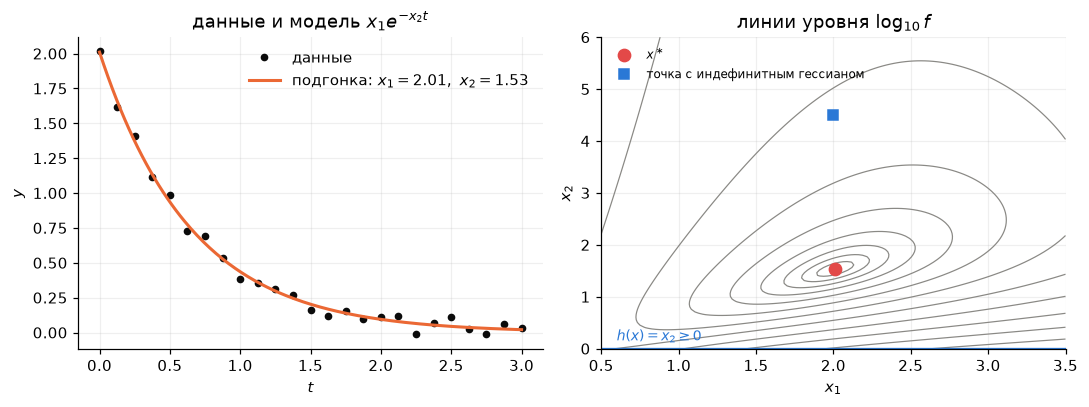

In [8]:
x1g = np.linspace(0.5, 3.5, 120); x2g = np.linspace(0.0, 6.0, 120)
X1, X2 = np.meshgrid(x1g, x2g)
F = np.array([[f([a, b]) for a in x1g] for b in x2g])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
ax = axes[0]
ax.plot(t, y, "o", color=INK, ms=4, label="данные")
tt = np.linspace(0, 3, 200)
ax.plot(tt, res.x[0] * np.exp(-res.x[1] * tt), color=ORANGE, lw=2, label=f"подгонка: $x_1={res.x[0]:.2f},\\ x_2={res.x[1]:.2f}$")
ax.set(xlabel="$t$", ylabel="$y$", title="данные и модель $x_1 e^{-x_2 t}$")
ax.legend()
ax = axes[1]
cs = ax.contour(X1, X2, np.log10(F), levels=14, colors=GRAY, linewidths=0.8, linestyles="solid")
ax.plot(*res.x, "o", color=RED, ms=8, zorder=5, label="$x^\\ast$")
ax.plot(2.0, 4.5, "s", color=BLUE, ms=7, zorder=5, label="точка с индефинитным гессианом")
ax.axhline(0, color=BLUE, lw=1.5)
ax.text(0.6, 0.15, "$h(x) = x_2 \\geq 0$", color=BLUE, fontsize=9)
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="линии уровня $\\log_{10} f$")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Слева — данные и найденная кривая; справа — линии уровня $f$ (в логарифмическом масштабе, иначе яму не видно). Яма одна и вытянутая, а выше неё, на плато, гессиан имеет отрицательное собственное число — функция невыпукла. Из старта на плато метод спуска может двигаться очень медленно: градиент там почти нулевой. Поэтому в нелинейном МНК выбор $x_0$ — часть постановки.

**Итог 12.1.** Четыре задачи — четыре класса: невыпуклая QP, невыпуклая QCQP, выпуклая QCQP, невыпуклая NLP со структурой суммы квадратов. Два наблюдения, которые стоит запомнить: квадрат нормы вместо нормы — стандартный приём, чтобы задача стала гладкой; нелинейное **равенство** почти всегда делает задачу невыпуклой, а то же выражение в виде неравенства «$\le$» — часто нет.

## 12.2. LP графически

> В примере 7.2 решите LP графически: нарисуйте допустимый многоугольник и линии уровня целевой функции. Убедитесь, что решение $(2, 6)$ — вершина. Какие ограничения активны? Что изменится, если прибыль от первого продукта вырастет до 10?

Задача: $\max 3x_1 + 5x_2$ при $x_1 \le 4$, $2x_2 \le 12$, $3x_1 + 2x_2 \le 18$, $x \ge 0$.

**Шаг 1. Многоугольник.** Каждое неравенство — полуплоскость; пересечение пяти полуплоскостей — пятиугольник с вершинами

| вершина | какие ограничения активны | прибыль $3x_1 + 5x_2$ |
|---|---|---|
| $(0, 0)$ | $x_1 \ge 0$, $x_2 \ge 0$ | $0$ |
| $(4, 0)$ | $x_1 \le 4$, $x_2 \ge 0$ | $12$ |
| $(4, 3)$ | $x_1 \le 4$, $3x_1 + 2x_2 \le 18$ | $27$ |
| $(2, 6)$ | $2x_2 \le 12$, $3x_1 + 2x_2 \le 18$ | $\mathbf{36}$ |
| $(0, 6)$ | $x_1 \ge 0$, $2x_2 \le 12$ | $30$ |

**Шаг 2. Линии уровня.** $3x_1 + 5x_2 = \text{const}$ — параллельные прямые с наклоном $-3/5$. Сдвигаем прямую в сторону роста прибыли (вверх-вправо), пока она не покинет многоугольник. Последняя точка касания — вершина $(2, 6)$, прибыль $36$.

**Почему всегда вершина.** Линии уровня линейной функции — прямые, а многоугольник выпуклый: прямая, покидающая его, последней касается либо вершины, либо целого ребра (если линия уровня параллельна ребру — тогда оптимальны все точки ребра, но и его концы-вершины тоже). Поэтому у LP всегда есть оптимальная вершина, и симплекс-метод (лекция 11) перебирает только вершины.

**Активные ограничения** в $(2, 6)$: второе ($2 \cdot 6 = 12$) и третье ($3 \cdot 2 + 2 \cdot 6 = 18$). Первое неактивно: $x_1 = 2 < 4$, запас $2$ — четвёртый цех недогружен.

**Шаг 3. Прибыль первого продукта растёт до 10.** Наклон линий уровня становится $-10/5 = -2$ — круче ребра $3x_1 + 2x_2 = 18$ (наклон $-3/2$). Теперь последней точкой касания оказывается соседняя вершина $(4, 3)$ с прибылью $10 \cdot 4 + 5 \cdot 3 = 55$; активными становятся ограничения 1 и 3.

Граница между двумя режимами — наклон линий уровня, равный наклону ребра: $c_1 / 5 = 3/2$, то есть $c_1 = 7.5$. При $c_1 < 7.5$ оптимум в $(2,6)$, при $c_1 > 7.5$ — в $(4,3)$, при $c_1 = 7.5$ оптимально всё ребро между ними. Решение LP при непрерывном изменении $c$ меняется **скачком** — это первый пример параметрической чувствительности (лекция 14).

In [9]:
A_ub = np.array([[1.0, 0.0], [0.0, 2.0], [3.0, 2.0]])
b_ub = np.array([4.0, 12.0, 18.0])
V = np.array([[0, 0], [4, 0], [4, 3], [2, 6], [0, 6]])          # вершины против часовой стрелки

def solve(c1, c2=5.0):
    res = linprog([-c1, -c2], A_ub=A_ub, b_ub=b_ub, bounds=[(0, None)] * 2, method="highs")
    return res.x, -res.fun, res.slack

for c1 in (3.0, 10.0):
    x, val, slack = solve(c1)
    active = [i + 1 for i, s in enumerate(slack) if abs(s) < 1e-9]
    print(f"c = ({c1:g}, 5): x* = {x}, прибыль = {val:g}, slack = {slack}, активны ограничения {active}")

c = (3, 5): x* = [2. 6.], прибыль = 36, slack = [2. 0. 0.], активны ограничения [2, 3]
c = (10, 5): x* = [4. 3.], прибыль = 55, slack = [0. 6. 0.], активны ограничения [1, 3]


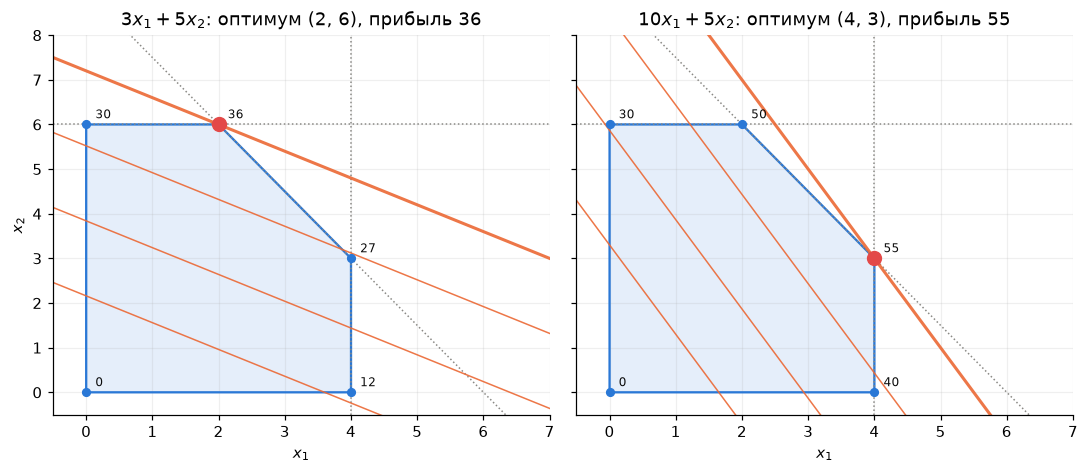

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True)
x1 = np.linspace(-0.5, 7, 200)
for ax, c1 in zip(axes, (3.0, 10.0)):
    ax.fill(V[:, 0], V[:, 1], color=BLUE, alpha=0.12, lw=0)
    ax.plot(*np.vstack([V, V[:1]]).T, color=BLUE, lw=1.5)
    ax.axvline(4, color=GRAY, lw=1, ls=":")
    ax.axhline(6, color=GRAY, lw=1, ls=":")
    ax.plot(x1, (18 - 3 * x1) / 2, color=GRAY, lw=1, ls=":")
    x_opt, val, _ = solve(c1)
    for lvl in np.linspace(0.3, 1.0, 4) * val:                     # линии уровня, последняя — через оптимум
        ax.plot(x1, (lvl - c1 * x1) / 5, color=ORANGE, lw=1 if lvl < val else 2, alpha=0.9)
    ax.plot(V[:, 0], V[:, 1], "o", color=BLUE, ms=5)
    ax.plot(*x_opt, "o", color=RED, ms=9, zorder=5)
    for v in V:
        ax.annotate(f"{c1 * v[0] + 5 * v[1]:g}", v, (6, 4), textcoords="offset points", fontsize=8, color=INK)
    ax.set(xlim=(-0.5, 7), ylim=(-0.5, 8), xlabel="$x_1$",
           title=f"${c1:g}x_1 + 5x_2$: оптимум {tuple(int(v) for v in x_opt.round())}, прибыль {val:g}")
axes[0].set_ylabel("$x_2$")
plt.tight_layout()
plt.show()

Числа у вершин — прибыль в каждой из них; оранжевые прямые — линии уровня, жирная проходит через оптимум. Слева (исходные коэффициенты) прямая последней касается $(2, 6)$, справа (прибыль первого продукта $10$) — $(4, 3)$. В `linprog` то же самое читается по `slack`: нули стоят у активных ограничений.

## 12.3. Невыпуклая функция и мультистарт

> Запустите `demo01.ipynb`, часть (d). Объясните, почему запуски из разных начальных точек дают разные ответы. Как найти глобальный минимум в одномерном случае? Почему этот приём не масштабируется на $n = 100$?

Функция $f(x) = (x^2 - 1)^2 + 0.3x$. Найдём её стационарные точки точно: $f'(x) = 4x^3 - 4x + 0.3$ — кубический многочлен, три вещественных корня. Знак $f''(x) = 12x^2 - 4$ говорит, минимум это или максимум.

In [11]:
f = lambda x: (x**2 - 1) ** 2 + 0.3 * x
df = lambda x: 4 * x**3 - 4 * x + 0.3
d2f = lambda x: 12 * x**2 - 4

roots = np.sort(np.roots([4, 0, -4, 0.3]).real)
for r in roots:
    kind = "минимум" if d2f(r) > 0 else "максимум"
    print(f"x = {r: .4f}:  f = {f(r): .4f},  f'' = {d2f(r): .2f}  ->  локальный {kind}")

x = -1.0356:  f = -0.3054,  f'' =  8.87  ->  локальный минимум
x =  0.0754:  f =  1.0113,  f'' = -3.93  ->  локальный максимум
x =  0.9601:  f =  0.2941,  f'' =  7.06  ->  локальный минимум


**Почему ответ зависит от старта.** BFGS (как и любой метод спуска) на каждой итерации уменьшает $f$ и останавливается там, где $f'(x) \approx 0$. У функции две «ямы», разделённые локальным максимумом $x \approx 0.075$. Метод идёт под горку и не может перепрыгнуть через горб: из старта левее максимума он попадает в левую яму (глобальный минимум), из старта правее — в правую (локальный). Множество стартов, приводящих в данный минимум, называется его **областью притяжения**. Проверим, запустив метод с сетки стартов.

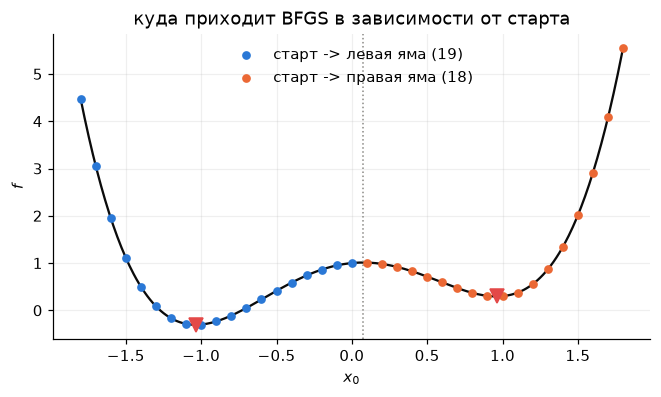

In [12]:
starts = np.linspace(-1.8, 1.8, 37)
found = np.array([minimize(lambda v: f(v[0]), [x0], jac=lambda v: [df(v[0])], method="BFGS").x[0] for x0 in starts])
left = found < 0

fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.linspace(-1.8, 1.8, 400)
ax.plot(x, f(x), color=INK, lw=1.5)
ax.scatter(starts[left], f(starts[left]), color=BLUE, s=22, zorder=4, label=f"старт -> левая яма ({left.sum()})")
ax.scatter(starts[~left], f(starts[~left]), color=ORANGE, s=22, zorder=4, label=f"старт -> правая яма ({(~left).sum()})")
ax.axvline(roots[1], color=GRAY, ls=":", lw=1)
ax.plot(roots[[0, 2]], f(roots[[0, 2]]), "v", color=RED, ms=9, zorder=5)
ax.set(xlabel="$x_0$", ylabel="$f$", title="куда приходит BFGS в зависимости от старта")
ax.legend(loc="upper center")
plt.show()

Граница областей притяжения — ровно локальный максимум (пунктир): старты слева от него окрашены в один цвет, справа — в другой. Метод не ошибается: он честно находит *ближайший по спуску* минимум.

**Как найти глобальный минимум при $n = 1$.** Перебором: посчитать $f$ на сетке (скажем, $1000$ точек отрезка), взять лучшую и запустить из неё локальный метод для уточнения. В одномерном случае это работает всегда, если сетка достаточно частая, чтобы не «проскочить» узкую яму.

In [13]:
grid = np.linspace(-2, 2, 1000)
x0 = grid[np.argmin(f(grid))]
res = minimize(lambda v: f(v[0]), [x0], jac=lambda v: [df(v[0])], method="BFGS")
print(f"лучшая точка сетки x0 = {x0:.4f}, после уточнения x* = {res.x[0]:.6f}, f* = {res.fun:.6f}")

лучшая точка сетки x0 = -1.0350, после уточнения x* = -1.035578, f* = -0.305428


**Почему это не масштабируется.** Сетка с $k$ точками по каждой из $n$ координат содержит $k^n$ узлов. При $n = 100$ даже грубая сетка из $k = 10$ точек — это $10^{100}$ вычислений $f$; для сравнения, атомов в наблюдаемой Вселенной около $10^{80}$. Это «проклятие размерности».

Случайный мультистарт (запустить локальный метод из многих случайных точек, оставить лучший результат) лучше сетки, но помогает лишь когда «ям» немного. А их число тоже может расти экспоненциально: у сепарабельной функции

$$F(x) = \sum_{i=1}^{n} \big[(x_i^2 - 1)^2 + 0.3 x_i\big]$$

каждая координата независимо выбирает одну из двух ям, и локальных минимумов ровно $2^n$. Глобальный — тот, где все $x_i$ сидят в левой (глубокой) яме. Посмотрим, что находит мультистарт из $200$ случайных точек при $n = 10$ и $n = 20$.

In [14]:
F = lambda x: np.sum((x**2 - 1) ** 2 + 0.3 * x)
dF = lambda x: 4 * x**3 - 4 * x + 0.3
n_starts = 200

for n in (10, 20):
    minima, best = set(), np.inf
    for _ in range(n_starts):
        res = minimize(F, rng.uniform(-1.8, 1.8, n), jac=dF, method="BFGS")
        minima.add(tuple(np.sign(res.x).astype(int)))           # яма кодируется знаками координат
        best = min(best, res.fun)
    f_glob = n * f(roots[0])
    print(f"n = {n:2d}: минимумов 2^n = {2**n:7d}, из {n_starts} стартов найдено разных: {len(minima):3d};  "
          f"лучшее F = {best:.4f}, глобальное F = {f_glob:.4f}  ->  {'найдено' if abs(best - f_glob) < 1e-6 else 'НЕ найдено'}")
print(f"при n = 100 минимумов было бы 2^100 = {2**100:.2e}")

n = 10: минимумов 2^n =    1024, из 200 стартов найдено разных: 177;  лучшее F = -2.4547, глобальное F = -3.0543  ->  НЕ найдено


n = 20: минимумов 2^n = 1048576, из 200 стартов найдено разных: 200;  лучшее F = -4.3098, глобальное F = -6.1086  ->  НЕ найдено
при n = 100 минимумов было бы 2^100 = 1.27e+30


Старт попадает в область притяжения глобального минимума, только если *все* координаты случайно легли левее горба — вероятность $\approx 0.5^{n}$. При $n = 10$ это $\approx 10^{-3}$, и двухсот стартов ещё может хватить; при $n = 20$ — уже $10^{-6}$, и мультистарт находит лишь крошечную долю минимумов, глобального среди них нет. При $n = 100$ шансов нет никаких.

Общего рецепта для невыпуклых задач не существует. Это и есть главная причина, по которой в оптимизации так ценят выпуклость: для выпуклой задачи локальный минимум — глобальный, и вопрос о старте снимается.

## Вопросы для самопроверки

Ответы на вопросы из конца конспекта.

**1. Допустимое множество, активное ограничение, минимумы.** Допустимое множество $\Omega = \{x : g(x) = 0,\ h(x) \ge 0\}$ — все точки, удовлетворяющие ограничениям. Неравенство $h_i$ активно в точке $x$, если $h_i(x) = 0$ (точка на его границе, «упёрлись»), неактивно, если $h_i(x) > 0$; равенства активны всегда. Точка $x^\ast \in \Omega$ — локальный минимум, если $f(x^\ast) \le f(x)$ для всех $x \in \Omega$ из некоторой окрестности $x^\ast$; глобальный, если для всех $x \in \Omega$. Строгий — когда неравенство строгое при $x \ne x^\ast$.

**2. Вейерштрасс и коэрцитивность.** Если $\Omega$ непусто и компактно (замкнуто и ограничено), а $f$ непрерывна на $\Omega$, глобальный минимум существует. Функция коэрцитивна, если $f(x) \to +\infty$ при $\Vert x\Vert \to \infty$; для замкнутого $\Omega$ и непрерывной $f$ это заменяет ограниченность: множество $\{x : f(x) \le f(x_0)\}$ — компакт, и на нём минимум есть по Вейерштрассу. Минимум не достигается: $\min e^x$ на $\mathbb{R}$ (инфимум $0$, функция не коэрцитивна), $\min x$ при $0 < x \le 1$ (множество не замкнуто), $\min x^3$ (не ограничена снизу).

**3. LP, QP, NLP и выпуклость.** LP: линейная цель, линейные ограничения. QP: квадратичная цель $\tfrac12 x^\top Q x + c^\top x$, ограничения линейные. NLP: произвольные гладкие $f$, $g$, $h$. LP $\subset$ QP $\subset$ NLP. Выпуклость важнее линейности, потому что для выпуклой задачи любой локальный минимум глобален и локальный метод решает её надёжно из любого старта. Невыпуклая QP с индефинитной $Q$ «почти линейна», но в общем случае NP-трудна; выпуклая NLP с нелинейными функциями решается надёжно.

**4. Как избавиться от модуля.** Ввести вспомогательную переменную-мажоранту: $s \ge |t|$ равносильно двум линейным неравенствам $-s \le t \le s$. Вместо $|t|$ минимизируем $s$; в решении $s = |t|$, потому что лишний запас можно уменьшить, не нарушив ограничений. Так же убирают $\max$ ($\max(a, b) \le s$ равносильно $a \le s$, $b \le s$), норму $\ell_1$ (сумма таких $s_i$) и норму $\ell_\infty$ (одна $s$ для всех невязок). Негладкая задача становится гладкой, часто LP или QP, ценой роста размерности.

## Что запомнить

- Стандартная форма — это таблица $x$, $f$, $g$, $h$; класс задачи определяется видом функций **и** выпуклостью, и это две разные оси (12.1).
- Квадрат нормы вместо нормы делает задачу гладкой, не меняя решения; нелинейное равенство почти всегда ломает выпуклость (12.1).
- Линейный МНК — выпуклая QP, нелинейный (модель нелинейна по параметрам) — уже NLP и, как правило, невыпуклая; сумма квадратов — структура, а не класс (12.1г).
- Решение LP — вершина; какая именно, зависит от направления $c$ и меняется скачком (12.2).
- Локальный метод находит минимум своей области притяжения; перебор стартов не масштабируется по $n$ (12.3).